###1. Importación de datos

In [ ]:
import pandas as pd

from google.colab import drive
drive.mount("/content/drive")

## Definir la raiz del sistema de archivos
raíz="/content/drive/MyDrive"

## Importar el archivo
solicitantes = pd.read_excel(raíz+"/0. SolicitantesCrédito (2).xlsx", sheet_name=2)

Mounted at /content/drive


In [ ]:
solicitantes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8378 entries, 0 to 8377
Data columns (total 35 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Unnamed: 0               8378 non-null   int64  
 1   Edad                     8378 non-null   int64  
 2   Sexo                     8378 non-null   object 
 3   Estado civil             8378 non-null   object 
 4   Hijos                    8378 non-null   int64  
 5   Perscargo                8378 non-null   int64  
 6   Estrato                  8378 non-null   int64  
 7   Nivel de estudios        8378 non-null   object 
 8   Tipo de contrato         8378 non-null   object 
 9   Ingresos                 8378 non-null   int64  
 10  Egresos                  8378 non-null   int64  
 11  Tipo de actividad        8378 non-null   object 
 12  Tipo de vivienda         8378 non-null   object 
 13  Total Activos            8378 non-null   float64
 14  Total pasivos           

###2. Limpieza de datos

In [ ]:
solicitantes.shape

(8378, 35)

In [ ]:
## Elimiar filas donde "PreApro" está vacio
XD=solicitantes.dropna(subset=["PreApr"])

In [ ]:
## Variables para completar el proceso de preaprobación del crédito
XD=XD[["Edad","Hijos","Perscargo","Estrato","Ingresos","Egresos","Monto (EAD)","Plazo","Cuota (COP)"]]
XD

,Edad,Hijos,Perscargo,Estrato,Ingresos,Egresos,Monto (EAD),Plazo,Cuota (COP)
0,38,1,0,3,5424576,7585302,2.815030e+06,48,82691.506204
1,51,6,1,4,1144064,1640079,6.301439e+05,36,22781.212598
2,37,2,0,3,2069853,2831440,1.280540e+06,36,46294.596244
3,29,1,0,2,1893080,2482276,1.393414e+06,24,69564.950015
4,42,3,4,2,3000367,3630221,2.252986e+06,24,112478.307883
...,...,...,...,...,...,...,...,...,...
8371,48,0,0,3,4831392,3392105,3.366188e+06,36,121695.762156
8373,31,2,0,5,5891088,4292158,3.918572e+06,48,115108.056436
8374,38,0,0,3,3092079,3028098,2.677266e+06,36,96789.562091
8375,43,1,2,2,2542007,3513112,1.375112e+06,36,49713.608249


In [ ]:
XD.head(10)

,Edad,Hijos,Perscargo,Estrato,Ingresos,Egresos,Monto (EAD),Plazo,Cuota (COP)
0,38,1,0,3,5424576,7585302,2.815030e+06,48,82691.506204
1,51,6,1,4,1144064,1640079,6.301439e+05,36,22781.212598
2,37,2,0,3,2069853,2831440,1.280540e+06,36,46294.596244
3,29,1,0,2,1893080,2482276,1.393414e+06,24,69564.950015
4,42,3,4,2,3000367,3630221,2.252986e+06,24,112478.307883
5,50,1,1,2,1957244,1900521,1.456173e+06,36,52644.131911
8,29,2,0,2,1114320,974703,1.072595e+06,18,68437.780632
9,42,0,0,5,2177515,2264288,2.262295e+06,36,81787.391384
10,64,1,1,2,1498127,1176843,1.600289e+06,36,57854.278715
12,25,0,2,3,1141254,915027,8.982021e+05,36,32472.159132


In [ ]:
# Variable dependiente
yd=solicitantes['PreApr'].dropna()

###3. Implementación del modelo Naive Bayes

In [ ]:
## Importación de librerias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.naive_bayes import GaussianNB

In [ ]:
## Datasets a arrays
XDArray = np.array(XD, dtype=float)
YDArray = np.array(yd, dtype=float)

In [ ]:
## Entrenar el modelo
modelNB = GaussianNB ()
modelNB.fit(XDArray, YDArray)

GaussianNB()

In [ ]:
## Predecir los yd
ydPred=modelNB.predict(XDArray)

###4. Matriz de confusión

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [ ]:
cm=confusion_matrix(YDArray, ydPred)
cm

array([[2539,  420],
       [1041, 1842]])

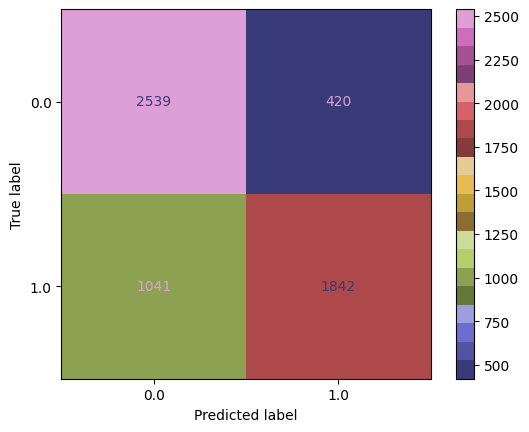

In [ ]:
disp=ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=modelNB.classes_)
disp.plot(cmap='tab20b')
plt.show()

Analisando la matriz de confusión se puede ver lo siguiente:
* TN= 2539, el modelo indica en una gran medida de forma correcta aquellos solicitantes que no deben de ser PreApr, para así reducir falsos positivos. Comparando el modelo con 4 variables a este con 9 se puede ver que los TN incrementaron, por lo que el modelo con más varibles puede indicar en mayor medida los solicitantes que no deben de ser PreApr.
* FN= 1041, el modelo debe de mejorar en esta área, ya que no está capturando todos los solicitantes que deben de ser PreApr. Comparando el modelo con 4 variables a este con 9, podemos ver que los FN aumentaron en buena medida, por lo que con más variables e modelo predice más veces solicitantes no preaprobados que en realidad si deberian de ser PreApr.
* FP= 420, está cifra muestra que el modelo tiene garn probabilidad de evitar preaprobar aquello que no debe de ser, lo que se puede interpretar como algo positivo. Con las 4 variables, el modelo evita más que se preaprobe lo que no debe de ser preaprobado.
* TP= 1842, al tener un número significativo de verdaderos positivos, indica que el modelo tiene gran capacidad para identificar positivamente los solicitantes aptos. Con las 4 variables, el modelo es aun mas capaz de identificar estso solicitantes aptos.

En general podemos ver que el modelo tiene buen nivel de especificidad evitando falsos positivos y es muy preciso para predicir cuando un solicitante debe ser preaprobado. Por otro lado, el modelo no está capturando la totalidad de los verdaderos psoitivos, lo que puede resultar en un alto número de FP. Para no sacrificar en gran medida la presición de los solicitantes, se pueden probar otros modelos.

###Calcular las métricas de evaluación del modelo

In [ ]:
## EXACTITUD
print(f'La exactitud del modelo es del {(cm[1][1] + cm[0][0])/cm.sum():.2%}')

La exactitud del modelo es del 74.99%


Que el modelo tenga una excatitud del casi 75% quiere decir que este puede predecir correctamente caundo debe ser preaprobado un solicitante y cuando no en una tercera cuarta parte. Esta es una cifra positiva pero puede mejorar. Comparando el desempeño del modelo con el de antes de 4 variables al de ahora con 9 se puede ver que la exactitud bajo en casi un 2% por lo que esta baja en el modelo con más variables.

In [ ]:
## Tasa de error
print(f'La tasa de error del modelo es del {(cm[1][0] + cm[0][1])/cm.sum():.2%}')

La tasa de error del modelo es del 25.01%


Al la tasa de error equivaler a un 25.01% quiere decir que en una cuarta parte de las predicciones que el modelo arroja son incorrectas. Aunque la cifra no sea tan alta, el modelo puede necesitar algunos ajustes. Comparando el desempeño del modelo con el de antes de 4 variables se puede ver que con 9 varaibles el modelo tiene una tasa de error un poco más amplia, por lo que esta sube en el modelo con más variables.

In [ ]:
## Precisión
print (f'La precisión del mdoelo es del {cm[1][1]/(cm[1][1]+cm[0][1]):.2%}')

La precisión del mdoelo es del 81.43%


El modelo tiene una precisión bastante alta, por lo que cuando este predice caundo se debe preaprobar un solicitante, tiene un porcentaje de razón de 81.43%, lo que significa que el modelo tiene un alto grado de confiabilidad en esto. Comparando el desempeño del modelo con el de antes de 4 variables al de ahora con 9 se puede ver que la presiicón del modelo mejora un poco en esta, por lo que sube con más variables.

In [ ]:
## Sensibilidad
print (f'La sensibilidad del mdoelo es del {cm[1][1]/(cm[1][1]+cm[1][0]):.2%}')

La sensibilidad del mdoelo es del 63.89%


El modelo tiene una sensibilidad del 63.89%, lo que significa que este tiene un porcentaje bastante alto de solicitantes que no está identificando. Comparando el desempeño del modelo con el de antes de 4 variables al de ahora con 9 se puede ver que la sensibilidad bajo un 4% con las 9 variables, por lo que aqui hay mas amplitud de solicitantes que el modelo no esta identificando.

In [ ]:
## Especificidad
print (f'La especificidad del mdoelo es del {cm[0][0]/(cm[0][0]+cm[0][1]):.2%}')

La especificidad del mdoelo es del 85.81%


El modelo con una especifidad del 85.81%, muestra que es efectivo en un gran nivel al identificar los solicitantes que no pueden ser preaprobados, lo que puede servir para bajar los falsos positivos. Comparando el desempeño del modelo con el de antes de 4 variables al de ahora con 9 se puede ver que la especifidad de este subio un 1%, lo cual es positivo ya que así el modelo es más efectivo para identificar solicitantes que no deben ser preaprobados.

###Desempeño:
El desempeño del modelo Naive Bayes es en general bueno, al tener cifras altas en las métricas de exactitud, presición y especificidad, lo que muestra un alto grado de confiabilidad del modelo a la hora de identificar de forma correcta los solicitantes deben ser preaprobados y los que no. Aunque por otro lado, las cifras de la sensibilidad y la tasa de error, muestran que el modelo debe de mejorar en identificar los solicitantes que si deben de ser preaprobados y que hay un margen del 25% que debe de mejorar este en sus predicciones. Haciendo la comparación del modelo con 4 variables a con 9, se ve que estás métricas pueden ser alteradas en una pequeña medida al incrementar las variables.

Como ya se menciono, si se quiere mejorar su desempeño, se pueden utilizar otros modelos para identificar de mejor manera las relaciones de los solicitantes.

###5. Pronóstico para Preaprobación de solicitantes nuevos

In [ ]:
## Filtrar solicitantes que todavía no tienen calificación
XDGener = solicitantes[solicitantes['PreApr'].isna()]
XDGener

,Unnamed: 0,Edad,Sexo,Estado civil,Hijos,Perscargo,Estrato,Nivel de estudios,Tipo de contrato,Ingresos,...,Plazo,Cuota (COP),ConoCliente,Garantia,RespPat,MoraCome,PreApr,Prob.Default (PD),Score,LGD
6,7,38,NR,Soltero,3,0,3,Profesional,Indefinido,1534711,...,60,2.009414e+04,Buenas Referencias,Sin Codeudor,Sin Patrimonio,Con Experiencia sin Mora,NaN,NaN,NaN,NaN
7,8,47,Mujer,Casado,0,0,2,Profesional,Ninguno,136750,...,48,3.563229e+03,Buena Experiencia CFB,Sin Codeudor,Sin Patrimonio,Con Experiencia sin Mora,NaN,NaN,NaN,NaN
11,12,46,Mujer,Casado,0,1,4,Primaria,Indefinido,7097220,...,3,1.090054e+06,Buenas Referencias,Con Codeudor(es),Prop.sin Hipoteca,Con Experiencia sin Mora,NaN,NaN,NaN,NaN
13,14,37,Mujer,Soltero,4,2,2,Técnico,Ninguno,1791987,...,48,6.856249e+04,Buena Experiencia CFB,Sin Codeudor,Prop.sin Hipoteca,Mora mayor a 60 Dìas,NaN,NaN,NaN,NaN
16,17,22,NR,Unión Libre,1,0,2,Bachiller,Fijo,2892545,...,36,6.824255e+04,Buenas Referencias,Sin Codeudor,Sin Patrimonio,Con Experiencia sin Mora,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8357,8358,24,NR,Casado,1,0,4,Técnico,Fijo,2433168,...,48,1.026380e+05,Buenas Referencias,Con Codeudor(es),Vehìculo sin Prenda,Sin experiencia,NaN,NaN,NaN,NaN
8358,8359,66,Hombre,Unión Libre,1,0,1,Técnico,Indefinido,83684,...,24,1.908509e+03,Buenas Referencias,Libranza Establecida,Sin Patrimonio,Mora mayor a 60 Dìas,NaN,NaN,NaN,NaN
8367,8368,32,NR,Unión Libre,0,1,4,Bachiller,Fijo,1133063,...,36,3.665316e+04,Buenas Referencias,Sin Codeudor,Sin Patrimonio,Con Experiencia sin Mora,NaN,NaN,NaN,NaN
8372,8373,35,Hombre,Separado,2,1,3,Primaria,Indefinido,3073152,...,18,1.375805e+05,Buenas Referencias,Con Codeudor(es),Sin Patrimonio,Con Experiencia sin Mora,NaN,NaN,NaN,NaN


In [ ]:
## Acotar el dataset a las columnas necesarias para generalizar
XDGener = XDGener[["Edad","Hijos","Perscargo","Estrato","Ingresos","Egresos","Monto (EAD)","Plazo","Cuota (COP)"]]
XDGener

In [ ]:
## Dataframe a array
XDGenerArray = np.array(XDGener, dtype=float)
XDGenerArray

In [ ]:
## Solicitar al modelo pronosticar la calificación PreApr a los solicitantes
ydGener = modelNB.predict(XDGenerArray)
ydGener

array([0., 0., 1., ..., 0., 0., 0.])

In [ ]:
ydGenerSerie = pd.Series(ydGener, index=solicitantes[solicitantes['PreApr'].isna()].index)
ydGenerSerie

,0
6,0.0
7,0.0
11,1.0
13,0.0
16,0.0
17,0.0
24,0.0
27,0.0
36,1.0
41,0.0


In [ ]:
solicitantes['PreApr'].fillna(ydGenerSerie, inplace=True)

In [ ]:
solicitantes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8378 entries, 0 to 8377
Data columns (total 35 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Unnamed: 0               8378 non-null   int64  
 1   Edad                     8378 non-null   int64  
 2   Sexo                     8378 non-null   object 
 3   Estado civil             8378 non-null   object 
 4   Hijos                    8378 non-null   int64  
 5   Perscargo                8378 non-null   int64  
 6   Estrato                  8378 non-null   int64  
 7   Nivel de estudios        8378 non-null   object 
 8   Tipo de contrato         8378 non-null   object 
 9   Ingresos                 8378 non-null   int64  
 10  Egresos                  8378 non-null   int64  
 11  Tipo de actividad        8378 non-null   object 
 12  Tipo de vivienda         8378 non-null   object 
 13  Total Activos            8378 non-null   float64
 14  Total pasivos           

In [ ]:
solicitantes.to_excel('PronósticoPreApr.xlsx')

In [ ]:
solicitantes.to_excel('/content/drive/MyDrive/PronósticoPreApr.xlsx')